### Synthetic data

In [11]:
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans
from matplotlib import pyplot as plt
import pandas as pd

X, y = make_moons(n_samples=300, noise=0.1, random_state=42)
print(X.min(), X.max())

-1.2272758742530834 2.2703863872199213


### KMeans

In [12]:
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X)

### DBSCAN

In [13]:
for eps in [0.1, 0.15, 0.2, 0.25, 0.3]:
    db = DBSCAN(eps=eps, min_samples=10)
    dbscan_labels = db.fit_predict(X)
    n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
    n_noise = list(dbscan_labels).count(-1)
    print(f"eps={eps}: klastrów={n_clusters}, punktów szumu={n_noise}")

eps=0.1: klastrów=1, punktów szumu=290
eps=0.15: klastrów=8, punktów szumu=71
eps=0.2: klastrów=2, punktów szumu=3
eps=0.25: klastrów=2, punktów szumu=0
eps=0.3: klastrów=1, punktów szumu=0


### Visualisation

Text(0.5, 1.0, 'DBSCAN')

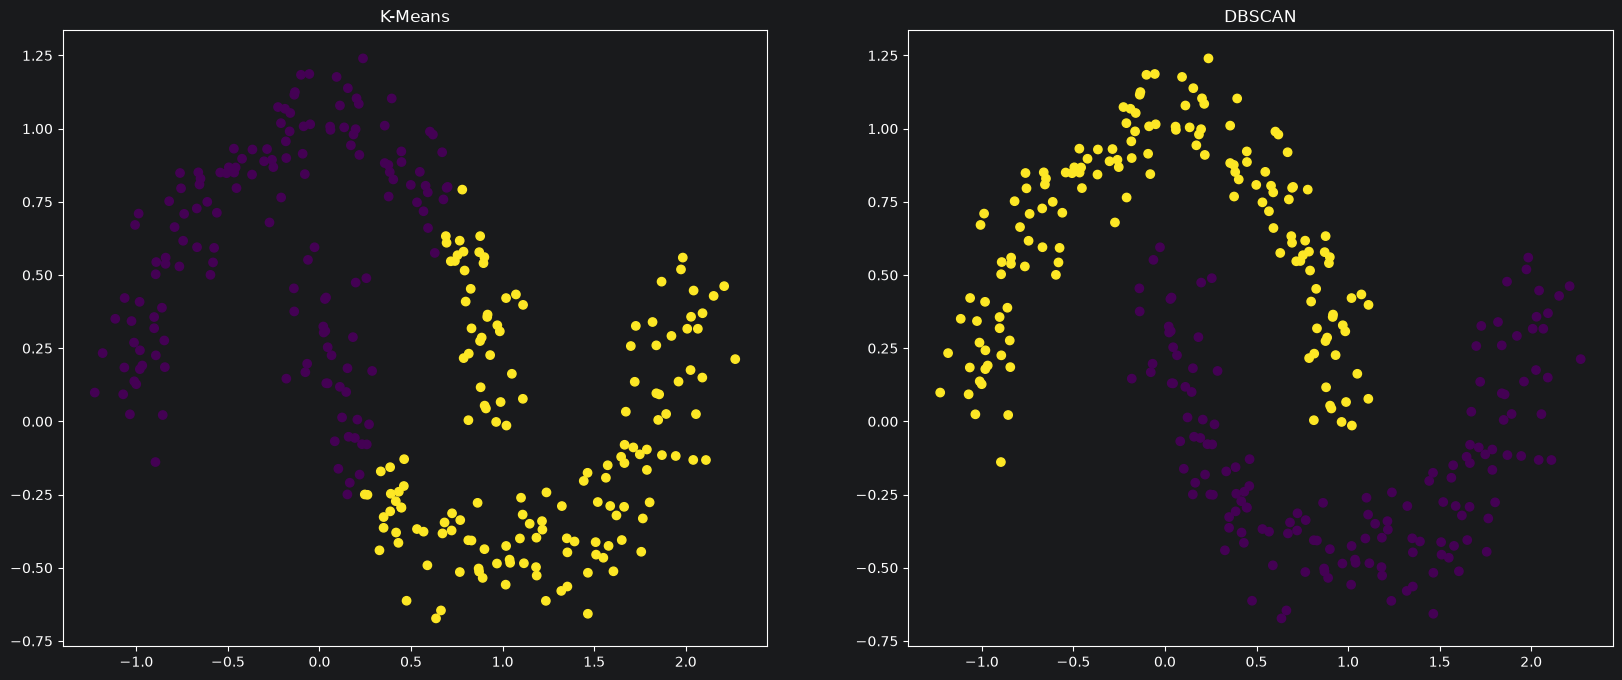

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

ax1.scatter(X[:, 0], X[:, 1], c=kmeans_labels, cmap='viridis')
ax1.set_title("K-Means")

db_final = DBSCAN(eps=0.25, min_samples=10)
dbscan_labels = db_final.fit_predict(X)
ax2.scatter(X[:, 0], X[:, 1], c=dbscan_labels, cmap='viridis')
ax2.set_title("DBSCAN")

In [16]:
pd.crosstab(y, kmeans_labels)

col_0,0,1
row_0,,
0,113,37
1,35,115


In [17]:
pd.crosstab(y, dbscan_labels)

col_0,0,1
row_0,,
0,0,150
1,150,0


### K-Means vs DBSCAN on make_moons — where K-Means fails and why

 - Observation: On two interleaving crescent shapes (make_moons, noise=0.1), K-Means
   (k=2) misclassifies 72/300 points (24% error) — visually, its cluster boundary cuts
   straight through both crescents rather than following their curved shape. DBSCAN
   (eps=0.25, min_samples=10) achieves a perfect match with the true labels (0 errors),
   with cluster boundaries that follow the natural curve of each crescent.
 - Interpretation: K-Means assigns every point to its nearest centroid, which mathematically
   produces a straight-line boundary (the perpendicular bisector between the two centroids)
   between any two clusters — this works well for roughly circular, well-separated blobs
   (like `wine`), but cannot represent a non-convex, curved shape. DBSCAN instead grows
   clusters by connecting points through local density, with no assumption about overall
   shape, so it naturally traces arbitrary curves as long as a density gap separates them.
 - Consequence: choosing K-Means vs. DBSCAN isn't just a matter of tuning parameters — it
   depends on whether the true clusters are expected to be convex/blob-shaped or
   irregular/curved. Also worth noting: DBSCAN's own assumption (a clear density gap between
   clusters) can break down under heavy noise — at noise=0.3 on this same dataset, neither
   algorithm could cleanly recover 2 clusters, showing that DBSCAN is not a universal fix,
   just a different set of trade-offs.